# Modeling Airbnb Listing Prices in Vancouver

#### DSCI 310 Sec 101, Group 01
#### Jialin Zhang, Richard He, Sean Holiday, Eddi Xie

## 0. Summary

A total of 4,621 Airbnb listings throughout Vancouver, Canada were analysed to determine which of their respective features were most strongly associated with rental pricing. The report utilises Exploratory Data Analysis (EDA) and a multiple linear regression model on a log scale to take outliers into account. 

## 1. Introduction

Airbnb is a company that acts as a middleman between homeowners and tourists through providing the former a platform to use their property as vacation rentals. 

The dataset used for this research project was detailed Airbnb listings data in Vancouver. This dataset held many features that detailed each listing in the city concerning the host (ex. response rate, superhost status), the property (ex. room type, neighbourhood, # of bedrooms), and the pricings. There are in total 79 features throughout this dataset and 5,685 rows. 

Many of these features are associated with the listing prices, however only some are expected to have strong links to them. Our goal is to determine which of these features have the strongest associations and potentially the reasons for such. 

Research Question:
**Which listing features are most strongly associated with Airbnb listing prices in Vancouver, British Columbia, and how are these features related to price?**

## 2. Methods and Results

### 2.1 Data Cleaning and Processing

In [1]:
library(tidyverse)
library(repr)
library(ggplot2)
library(dplyr)
library(readr)
library(stringr)
library(patchwork)
library(car)
library(broom)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




In [2]:
# Import the dataset
raw_airbnb <- read.csv("data/raw/listings.csv")

In [3]:
# Set a random seed to ensure reproducibility
set.seed(310)

# Keep the target variable and most relevant columns
# Keep 'id' as a character variable
# Remove rows where 'price' is empty, and transfer 'price' into a numeric variable
airbnb <- raw_airbnb %>%
  select(
    id, host_is_superhost, neighbourhood_cleansed, property_type, room_type, 
    accommodates, bathrooms, bedrooms, price, review_scores_rating, reviews_per_month
  ) %>%
  mutate(id = as.character(id)) %>%
  filter(!is.na(price), price != "") %>%
  mutate(
    price = price %>%
      str_remove_all("[$,]") %>%
      as.numeric()
  ) %>%
  filter(!is.na(price)) %>%
  # Explicitly drop rows with missing values in your model's predictors
  drop_na(accommodates, bedrooms, bathrooms, room_type, property_type)

In [4]:
# Refactor 'host_is_superhost' to 'Yes', 'No', "Unknown'
airbnb <- airbnb %>%
  mutate(
    host_is_superhost = case_when(
      host_is_superhost == "t" ~ "Yes",
      host_is_superhost == "f" ~ "No",
      host_is_superhost == " " ~ "Unknown",
      is.na(host_is_superhost) ~ "Unknown",
      TRUE ~ "Unknown"
    ),
    host_is_superhost = as.factor(host_is_superhost)
  )

In [5]:
# Check the number of unique property types and neighbourhood
length(unique(airbnb$property_type))
length(unique(airbnb$neighbourhood_cleansed))

[1] 42

[1] 23

Since the number of unique property types and neighbourhoods is large, including all categories may reduce model stability and interpretability. Therefore, we merge less frequent property types and neighbourhoods into a single category labelled “Other”.

In [6]:
# Find out the 4 most frequent property types
top4_property <- airbnb %>%
  count(property_type, sort = TRUE) %>%
  slice_head(n = 4) %>%
  pull(property_type)

# Merge the remaining values into "Other"
airbnb <- airbnb %>%
  mutate(property_type = ifelse(property_type %in% top4_property,
                                property_type,
                                "Other"),
         property_type = as.factor(property_type))

In [7]:
# Find out the 4 most frequent neighbourhoods
top4_neighbourhoods <- airbnb %>%
  count(neighbourhood_cleansed, sort = TRUE) %>%
  slice_head(n = 4) %>%
  pull(neighbourhood_cleansed)

# Merge the remaining values into "Other" and rename the column
airbnb <- airbnb %>%
  mutate(neighbourhood = ifelse(neighbourhood_cleansed %in% top4_neighbourhoods,
                                neighbourhood_cleansed,
                                "Other"),
         neighbourhood = as.factor(neighbourhood))

In [8]:
head(airbnb)

,id,host_is_superhost,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,price,review_scores_rating,reviews_per_month,neighbourhood
,<chr>,<fct>,<chr>,<fct>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<fct>
1,13188,Yes,Riley Park,Other,Entire home/apt,4,1,0,136,4.85,1.99,Other
2,13358,Yes,Downtown,Entire condo,Entire home/apt,2,1,1,188,4.71,3.11,Downtown
3,18270,No,Mount Pleasant,Other,Private room,2,1,1,47,4.54,0.66,Mount Pleasant
4,18589,Yes,Grandview-Woodland,Private room in home,Private room,2,1,1,123,4.98,3.60,Other
5,18795,No,West End,Private room in home,Private room,2,1,1,75,4.56,0.74,Other
6,20085,No,Kensington-Cedar Cottage,Other,Entire home/apt,3,1,2,90,4.80,0.42,Other


### 2.2 Exploratory Data Analysis

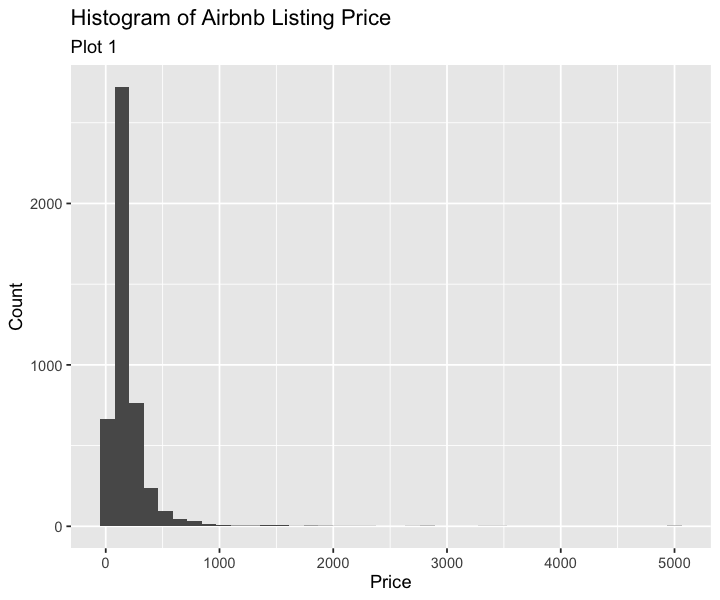

In [9]:
options(repr.plot.width = 6, repr.plot.height = 5)

# Plot a histogram of 'price'
p1 <- ggplot(airbnb, aes(x = price)) + 
  geom_histogram(bins = 40) + 
  labs(title = "Histogram of Airbnb Listing Price", 
       x = "Price", y = "Count", subtitle = "Plot 1")

p1

Since the distribution of `price` is extremely right-skewed, we apply a log transformation and use **log-transformed price** `log_price` in the regression analysis to improve normality and stabilize variance.

In [10]:
# Create a column called 'log_price'
airbnb <- airbnb %>%
  mutate(log_price = log(price))

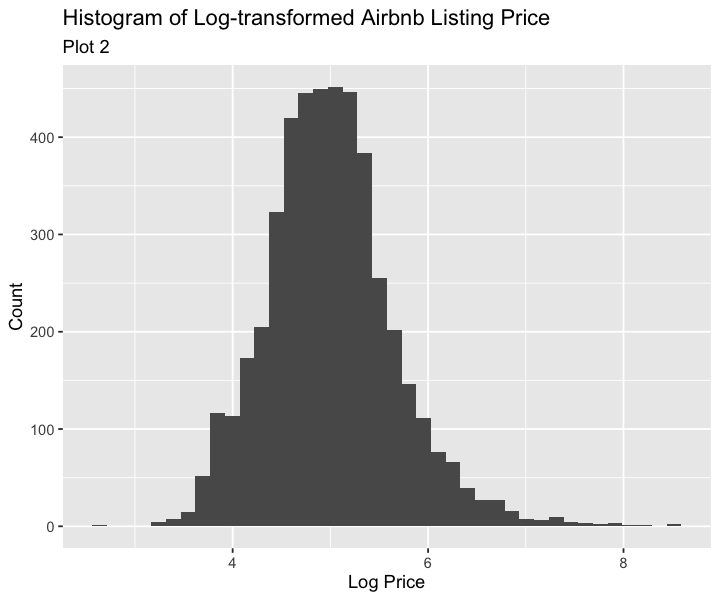

In [11]:
options(repr.plot.width = 6, repr.plot.height = 5)

# Plot a histogram of 'log_price'
p2 <- ggplot(airbnb, aes(x = log_price)) + 
  geom_histogram(bins = 40) + 
  labs(title = "Histogram of Log-transformed Airbnb Listing Price", 
       x = "Log Price", y = "Count", subtitle = "Plot 2")

p2

We will conduct an exploratory data analysis (EDA) to identify the variables that are most strongly associated with `log_price`. These variables are then selected as predictors in the multiple linear regression model.

#### 2.2.1 Analyze Numeric Variables

In [12]:
# Select numeric variables
numeric_vars <- airbnb %>%
  select(log_price, accommodates, bathrooms, bedrooms,
         review_scores_rating, reviews_per_month)

# Compute the correlation between log_price and numeric predictors
cor(numeric_vars, use = "complete.obs")["log_price", ] %>%
  enframe(name = "variable", value = "correlation") %>%
  filter(variable != "log_price") %>%
  arrange(desc(abs(correlation)))

variable,correlation
<chr>,<dbl>
accommodates,0.5802308
bedrooms,0.5551811
bathrooms,0.5269483
review_scores_rating,0.1726906
reviews_per_month,-0.0365348


The table shows the Pearson correlation coefficients between `log_price` and the numeric predictors. Variables such as `accommodates`, `bedrooms` and `bathrooms` show **moderately strong correlations**, as their coefficients are larger than 0.5. Variables such as `review_scores_rating` and `reviews_per_month` with very small absolute correlations show **no linear relationship** with `log_price`.

#### 2.2.2 Analyzing Categorical Variables

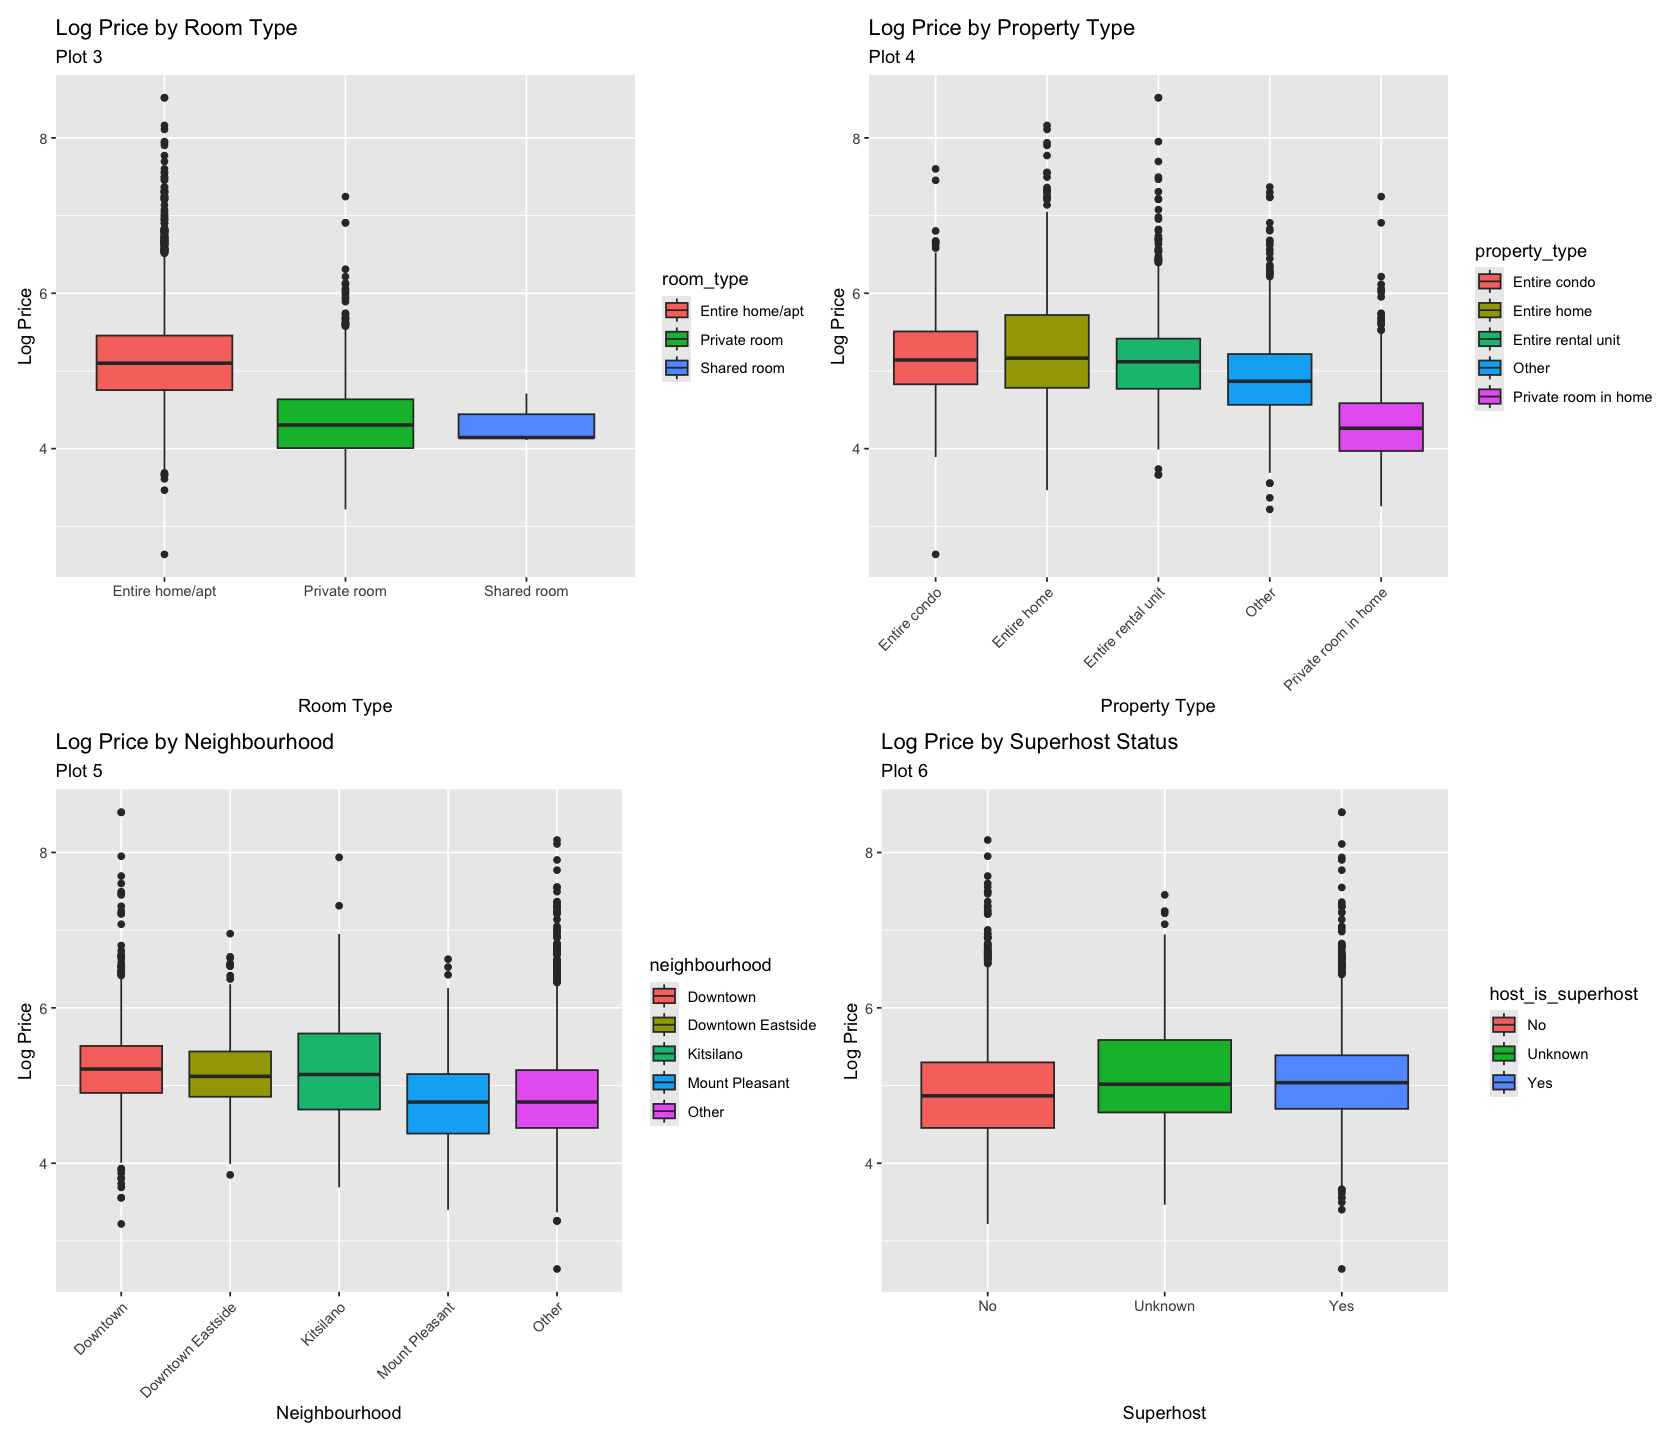

In [13]:
options(repr.plot.width = 14, repr.plot.height = 12)

# Boxplot: Room Type vs. Log Price
p3 <- ggplot(airbnb, aes(x = room_type, y = log_price, fill = room_type)) +
  geom_boxplot() +
  labs(title = "Log Price by Room Type",
       x = "Room Type",
       y = "Log Price",
       subtitle = "Plot 3")

# Boxplot: Property Type vs. Log Price
p4 <- ggplot(airbnb, aes(x = property_type, y = log_price, fill = property_type)) +
  geom_boxplot() +
  labs(title = "Log Price by Property Type",
       x = "Property Type",
       y = "Log Price",
       subtitle = "Plot 4") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Boxplot: Neighbourhood vs. Log Price
p5 <- ggplot(airbnb, aes(x = neighbourhood, y = log_price, fill = neighbourhood)) +
  geom_boxplot() +
  labs(title = "Log Price by Neighbourhood",
       x = "Neighbourhood",
       y = "Log Price",
       subtitle = "Plot 5") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Boxplot: Superhost Status vs. Log Price
p6 <- ggplot(airbnb, aes(x = host_is_superhost, y = log_price, fill = host_is_superhost)) +
  geom_boxplot() +
  labs(title = "Log Price by Superhost Status",
       x = "Superhost",
       y = "Log Price", 
       subtitle = "Plot 6")

(p3 | p4) / (p5 | p6)

The boxplots illustrate the relationship between `log_price` and four categorical variables. Plot 3 shows clear difference in log price range and median log prices across different room types, with entire homes having higher prices than private or shared rooms. Plot 4 also shows clear differences in median log prices across different property types. In contrast, Plot 5 and Plot 6 show more overlap among groups. Therefore, `room_type` and `property_type` **appear to be stronger predictors of** `log_price` and are more suitable to be included in the regression model.

### 2.3 Check Multicollinearity

Based on the exploratory data analysis, we initially selected five variables (`bathrooms`, `accommodates`, `bedrooms`, `room_type`, and `property_type`) as potential predictors of `log_price`. Before finalizing the model, we need to conduct a **Variance Inflation Factor (VIF) analysis to check multicollinearity**, which refers to the situation where predictor variables are highly correlated with one another, inflate standard errors and reduce model stability. 

In [14]:
# Build a test model using accommodates, bedrooms, bathrooms, room_type and property_type for multicollinearity check
model_vif <- lm(
  log_price ~ accommodates + bedrooms + bathrooms + room_type + property_type,
  data = airbnb
)

# Find out the VIF value for each variable
vif(model_vif) %>%
  as.data.frame() %>%
  select(`GVIF^(1/(2*Df))`) %>%
  rename(VIF = `GVIF^(1/(2*Df))`) %>%
  tibble::rownames_to_column("Variable")

Variable,VIF
<chr>,<dbl>
accommodates,1.977891
bedrooms,2.067255
bathrooms,1.483987
room_type,1.470269
property_type,1.230280


The VIF result shows that all the variables have VIF values below 5, indicating low levels of multicollinearity. Therefore, we will use all five variables in the final multiple linear regression model.

### 2.4 Modeling

In [15]:
# Build the multiple linear regression model using accommodates, bedrooms, bathrooms, room_type and property_type
airbnb_model <- lm(
    log_price ~ accommodates + bedrooms + bathrooms + room_type + property_type, 
    data = airbnb
)

print(airbnb_model)


Call:
lm(formula = log_price ~ accommodates + bedrooms + bathrooms + 
    room_type + property_type, data = airbnb)

Coefficients:
                      (Intercept)                       accommodates  
                          4.50376                            0.05252  
                         bedrooms                          bathrooms  
                          0.10572                            0.26295  
            room_typePrivate room               room_typeShared room  
                         -0.34912                           -0.40278  
         property_typeEntire home    property_typeEntire rental unit  
                         -0.19407                           -0.05684  
               property_typeOther  property_typePrivate room in home  
                         -0.14717                           -0.34638  



The estimated multiple linear regression model is:

**log_price = 4.50376 + 0.05252 * accommodates + 0.10572 * bedrooms + 0.26295 * bathrooms - 0.34912 * PrivateRoom - 0.40278 * SharedRoom - 0.19407 * EntireHome - 0.05684 * EntireRentalUnit - 0.14717 * Other - 0.34638 * PrivateRoomInHome**

## 3. Discussion

### 3.1 Interpreting and Evaluating the Model

In [16]:
summary(airbnb_model)


Call:
lm(formula = log_price ~ accommodates + bedrooms + bathrooms + 
    room_type + property_type, data = airbnb)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.81213 -0.31698 -0.03115  0.25681  2.96225 

Coefficients:
                                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        4.503764   0.023805 189.195  < 2e-16 ***
accommodates                       0.052517   0.006597   7.960 2.14e-15 ***
bedrooms                           0.105725   0.015045   7.027 2.42e-12 ***
bathrooms                          0.262952   0.014990  17.542  < 2e-16 ***
room_typePrivate room             -0.349121   0.036927  -9.454  < 2e-16 ***
room_typeShared room              -0.402775   0.141786  -2.841  0.00452 ** 
property_typeEntire home          -0.194065   0.024524  -7.913 3.12e-15 ***
property_typeEntire rental unit   -0.056844   0.022412  -2.536  0.01124 *  
property_typeOther                -0.147171   0.024517  -6.003 2.09e-09 ***
prop

`height` was translated to `width`.


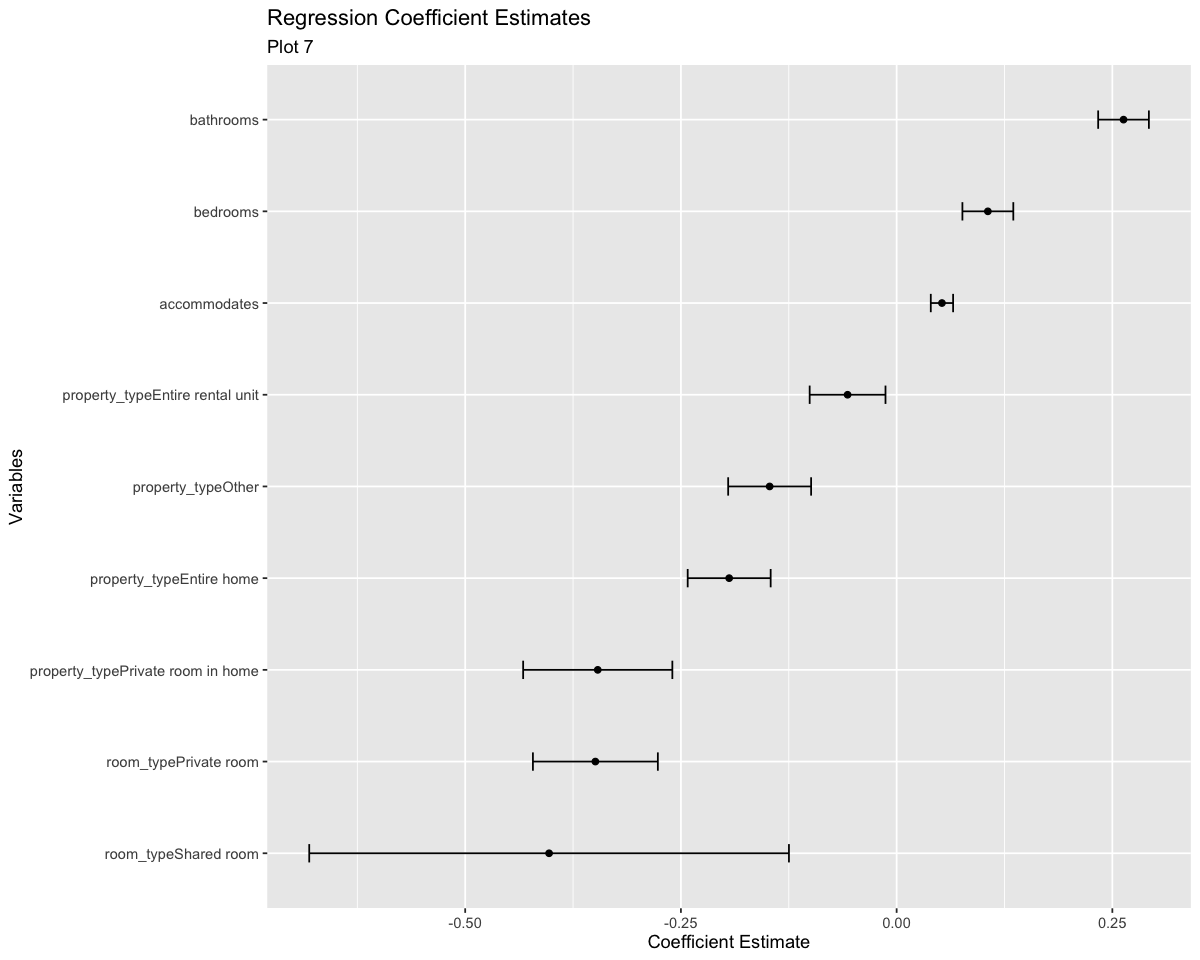

In [17]:
options(repr.plot.width = 10, repr.plot.height = 8)

# Plot a Coefficient Plot of the model
tidy_model <- tidy(airbnb_model, conf.int = TRUE)

p7 <- ggplot(tidy_model %>% filter(term != "(Intercept)"),
       aes(x = estimate, y = reorder(term, estimate))) +
  geom_point() +
  geom_errorbar(aes(xmin = conf.low, xmax = conf.high), height = 0.2) +
  labs(title = "Regression Coefficient Estimates",
       x = "Coefficient Estimate",
       y = "Variables",
       subtitle = "Plot 7")

p7

Some interpretation of the input variables are that all numeric inputs hold a positive relationship with price. `bathrooms` has the most impactful feature with a coefficient of 0.26. The other numerical features `bedrooms` (coefficient: 0.11) and `accommodates` (coefficient: 0.05) also drive price upwards. 

`room_type` and `property_type` being negative coefficients indicate that these features decrease price relative to their baseline categories (`Entire home/apt` and `Entire condo`). Listing a `Private room` (-0.35) or `Shared room` (-0.40) can drastically reduce the expected price compared to the entire apartment. Similarly in the case of the `entire condo` baseline, `Entire rental unit` (-0.06) and `Entire home` (-0.19) have smaller but still negative price differences compared to the baseline

Based on the Adjusted R-squared value, the model yielded an adjusted r-squared of 0.491 meaning that the selected five predictors were able to successfully explain 49.1% of all variance in the log-transformed prices. The outputted F-statistic (494.8, p < 2.2e-16) indicates that this model is highly significant. Every predictor was statistically significant with only `room_typeShared room` and `property_typeEntire` rental unit sitting at the highest p-values but were still well below the standard 0.05 threshold. 

The plot visualizes that `bathrooms` sitting at the far right is clearly the most powerful positive driver with a very tight confidence interval. Meanwhile, the room types and private room predictors sit further left, visually confirming how lack of privacy is a negative factor on a listing's price. The extremely wide confidence interval for the predictor `room_typeShared_room` can likely be due to a smaller sample size of this category in the selected sample from the dataset. 

### 3.2 Summary

The analysis revealed that physical capacity and privacy levels held the strongest associations with a listing's price. The multiple linear regression model revealed specifically that the `accommodates` (r=0.58), `bedrooms` (r=0.56), and `bathrooms` (r=0.53) features had strong positive relationships with price. This was confirmed via the MLR model as adding one additional bathroom became associated with a 30.1% increase in price. Categorical features like `room_type` and `property_type` heavily dictated the baseline cost. Features that were centered more around the host lacked a strong enough relationship with price. For example, `review_scores_rating` held an r score of only 0.17. We expected host status and review scores to play a much bigger role than they actually did. This was surprising as one would generally expect the owner of the accommodation to leverage their superhost status and review scores for whether they'd price higher or not. 

### 3.3 Key Takeaway

A key takeaway is for tourists looking for accommodation in the city. Naturally, the premium sounding name of "superhost" would get people to believe that properties owned by them would be more expensive to stay in. However with these results, budget-conscious tourists can conduct better research into their accommodations by placing less of a consideration on the hosts' status and more on filtering out listings with unneeded bathroom counts. 

### 3.4 Future Analysis

Further research should be conducted on superhost status and these ratings. Although they may not be of use to the tourist, it should be questioned how much significance it has for the host to strive for good metrics in these features through exploring what features these do have a strong association with. 

## 4. References

Belsley, D. A., Kuh, E., & Welsch, R. E. (2005). Regression diagnostics: Identifying influential data and sources of collinearity. John Wiley & Sons.

Draper, N. R., & Smith, H. (1998). Applied regression analysis (Vol. 326). John Wiley & Sons.

Lee, D. K. (2020). Data transformation: a focus on the interpretation. Korean journal of anesthesiology, 73(6), 503-508.

Weissfeld, L. A., & Sereika, S. M. (1991). A multicollinearity diagnostic for generalized linear models. Communications in Statistics-Theory and Methods, 20(4), 1183-1198.